<a href="https://colab.research.google.com/github/ghawkes333/KneeMRIClassifier/blob/main/explore_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

GenAI: I used Claude and HuggingFaceAI to learn how to download a set of npz files from HuggingFaceHub. I used Gemini to draft code to load the model and run inference on MedGamma. I used Gemini to identify possible solutions to an Out of Memory issue.

Reference for fine tuning MedGamma: https://github.com/google-health/medgemma/blob/main/notebooks/fine_tune_with_hugging_face.ipynb

In [1]:
!pip install bitsandbytes
!pip install accelerate

In [2]:
from datasets import load_dataset
from huggingface_hub import login
from huggingface_hub import hf_hub_download
from datasets import Dataset, concatenate_datasets
from transformers import pipeline
import numpy as np
from huggingface_hub import snapshot_download
import glob

In [3]:
login()

In [4]:
# sing_coil = load_dataset("AUMLProject/fastmri-knee-singlecoil-rss")
def download_one_example():
  filepath1 = hf_hub_download(
      repo_id="AUMLProject/fastmri-knee-singlecoil-rss",
      filename="data/file1000001.npz",
      repo_type="dataset"
  )
  npz1 = np.load(filepath1)

  return npz1

In [5]:
example = download_one_example()
print(example)

data/file1000001.npz:   0%|          | 0.00/30.6M [00:00<?, ?B/s]

NpzFile '/root/.cache/huggingface/hub/datasets--AUMLProject--fastmri-knee-singlecoil-rss/snapshots/be54b608d0ea125707a5bd69d4879fb27677c3a4/data/file1000001.npz' with keys: images, filename, num_slices, height, width...


In [6]:

import torch
from transformers import AutoProcessor, AutoModelForImageTextToText
from PIL import Image
import bitsandbytes as bnb
import accelerate
from transformers import pipeline

In [7]:
model_id = "google/medgemma-1.5-4b-it"

In [8]:


def predict_acl(sample, pipe):
    # Extract the image (assuming 'images' is a path or a numpy array in the npz)
    # Most npz datasets store a stack; we'll take the middle slice
    mri_stack = np.load(sample['images'])['data'] if isinstance(sample['images'], str) else sample['images']
    mid_slice = mri_stack[int(sample['num_slices']) // 2]

    # Normalize and convert to PIL
    rescaled = (255.0 / mid_slice.max() * (mid_slice - mid_slice.min())).astype(np.uint8)
    image = Image.fromarray(rescaled)

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": "Does this knee MRI show an ACL (Anterior Cruciate Ligament) injury? Answer 'Yes' or 'No' and provide a brief reason."},
                {"type": "image", "image": image}
            ]
        }
    ]

    with torch.no_grad():
      output = pipe(text=messages, max_new_tokens=50, do_sample=False, use_cache=False)
      response = output[0]["generated_text"][-1]["content"]

    return response



In [9]:
# Run on the first file
from transformers import BitsAndBytesConfig
sample_file = example


model_kwargs = dict(
    device_map="auto",
    quantization_config=BitsAndBytesConfig(load_in_4bit=True) # Loads the weights in 4bit pieces, allowing a larger model to fit. Speeds up inference but much slower to load initially
)

pipe = pipeline("image-text-to-text", model=model_id, model_kwargs=model_kwargs)

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
print(f"Predicting for: {sample_file['filename']}")
print(predict_acl(sample_file, pipe))

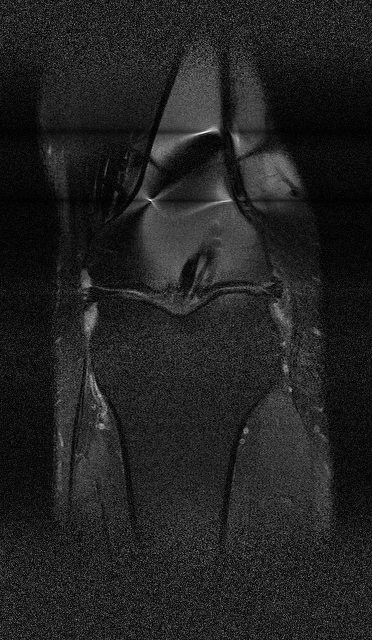

In [44]:
# Show image
from torchvision import transforms
from torch import Tensor
from sklearn.preprocessing import normalize

def show_im(sample):
    mri_stack = np.load(sample['images'])['data'] if isinstance(sample['images'], str) else sample['images']
    mid_slice = mri_stack[int(sample['num_slices']) // 2].astype(np.float16)
    mid_slice = 255* normalize(mid_slice)

    rescaled = (255.0 / mid_slice.max() * (mid_slice - mid_slice.min())).astype(np.uint8)

    image = Image.fromarray(rescaled)
    display(image)

show_im(sample_file)

In [ ]:
# TODO: Check if this downloads fully and concats the datasets correctly
def download_full_singlecoil_dataset():
  local_dir = snapshot_download(
      repo_id="AUMLProject/fastmri-knee-singlecoil-rss",
      repo_type="dataset",
      allow_patterns="*.npz",

  )

  datasets = []
  for filepath in sorted(glob.glob(f"{local_dir}/data/*.npz")):
      npz = np.load(filepath, allow_pickle=True)
      datasets.append(Dataset.from_dict({k: npz[k] for k in npz.files}))

  dataset = concatenate_datasets(datasets)

  return dataset

  print(local_dir)
